Employee


In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    'age': np.random.randint(22, 60, n),
    'experience': np.random.randint(1, 20, n),
    'salary': np.random.randint(20000, 150000, n),
    'department': np.random.choice(['IT', 'HR', 'Sales', 'Finance'], n),
    'training_hours': np.random.randint(0, 100, n),
    'projects_completed': np.random.randint(1, 20, n),
    'attendance_rate': np.random.uniform(0.5, 1.0, n)
})

# Create performance label
def assign_performance(row):
    score = (
        row['experience'] * 0.3 +
        row['training_hours'] * 0.2 +
        row['projects_completed'] * 0.3 +
        row['attendance_rate'] * 100 * 0.2
    )
    if score > 80:
        return "High"
    elif score > 50:
        return "Medium"
    else:
        return "Low"

data['performance'] = data.apply(assign_performance, axis=1)

data.head()

,age,experience,salary,department,training_hours,projects_completed,attendance_rate,performance
0,50,17,114031,IT,9,7,0.638923,Low
1,36,13,51750,Sales,52,17,0.885756,Low
2,29,16,115155,HR,43,3,0.825950,Low
3,42,8,60461,Sales,46,5,0.916209,Low
4,40,19,93800,Sales,52,19,0.987737,Low


Basic checks

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 1000 non-null   int64  
 1   experience          1000 non-null   int64  
 2   salary              1000 non-null   int64  
 3   department          1000 non-null   object 
 4   training_hours      1000 non-null   int64  
 5   projects_completed  1000 non-null   int64  
 6   attendance_rate     1000 non-null   float64
 7   performance         1000 non-null   object 
dtypes: float64(1), int64(5), object(2)
memory usage: 62.6+ KB


In [5]:
data.columns

Index(['age', 'experience', 'salary', 'department', 'training_hours',
       'projects_completed', 'attendance_rate', 'performance'],
      dtype='object')

In [7]:
data.shape

(1000, 8)

In [8]:
data.describe()

,age,experience,salary,training_hours,projects_completed,attendance_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.947000,9.931000,81924.107000,50.186000,10.299000,0.744959
std,11.160858,5.466088,37496.376085,28.229494,5.313552,0.143336
min,22.000000,1.000000,20155.000000,0.000000,1.000000,0.500093
25%,31.000000,5.000000,48716.000000,26.000000,6.000000,0.621872
50%,42.000000,10.000000,79794.000000,51.000000,11.000000,0.739750
75%,50.000000,15.000000,114445.000000,74.000000,15.000000,0.868976
max,59.000000,19.000000,149951.000000,99.000000,19.000000,0.998759


EDA Visualize

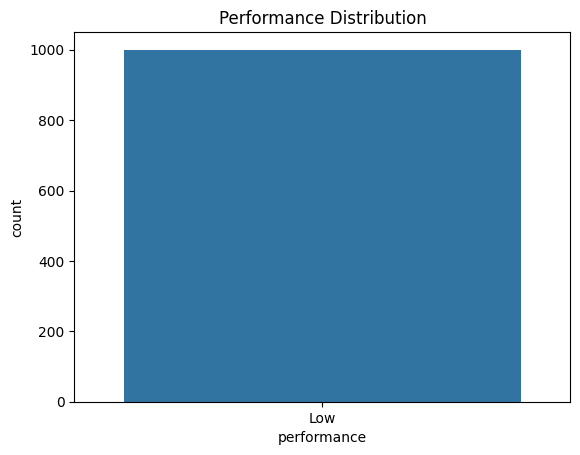

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='performance', data=data)
plt.title("Performance Distribution")
plt.show()

Preprocessing

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical
data['department'] = LabelEncoder().fit_transform(data['department'])
data['performance'] = LabelEncoder().fit_transform(data['performance'])

X = data.drop('performance', axis=1)
y = data['performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Model ttraining

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

Evaluation

In [12]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Prediction

In [13]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Predicted Performance:", prediction)

Predicted Performance: [0]
